NameError: name 'title' is not defined

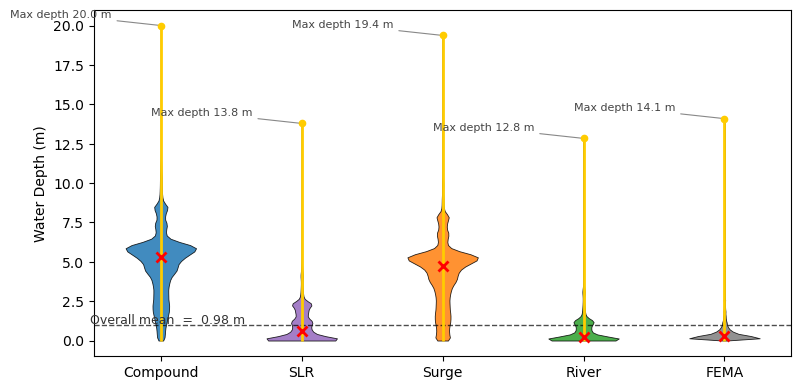

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------------------- INPUTS --------------------
paths = {
    "Compound": r"D:\Phd Research\sim_depth_100yr.tif",
    "SLR":      r"D:\Phd Research\inundation depth only SLR.tif",
    "Surge":    r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    "River":    r"D:\Phd Research\inundation depth 100 yr river flow.tif",
    "FEMA":     r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif",
}

drop_below = 0.0     # keep depths strictly > this value; set to 0.1 if you want to ignore near-dry pixels
ymax = 10.0          # set to None for auto; set to 12.0 to match your figure
# title = "Water Depth Distributions"
# ------------------------------------------------

# Nice distinct colors (match your visual style)
colors = {
    "Compound": "#1f77b4",  # blue
    "SLR":      "#9467bd",  # puple (adjust if you want exact)
    "Surge":    "#ff7f0e",  # orange
    "River":    "#2ca02c",  # green
    "FEMA":     "#7f7f7f",  # gray
}
# If you prefer SLR bluish and Compound blue, tweak the dict above.

def read_depths(path, drop_below=0.0):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    if nodata is not None:
        valid = (arr != nodata) & np.isfinite(arr)
    else:
        valid = np.isfinite(arr)
    vals = arr[valid]
    if drop_below is not None:
        vals = vals[vals > drop_below]
    return vals

# Load all datasets
series = {}
for label, p in paths.items():
    vals = read_depths(p, drop_below=drop_below)
    if vals.size == 0:
        print(f"Warning: no valid depths found for {label}")
    series[label] = vals

# Prepare data for violinplot (list of arrays in consistent order)
labels = list(paths.keys())
data = [series[l] for l in labels]

# Overall mean across all drivers
all_vals = np.concatenate([v for v in data if v.size > 0])
overall_mean = float(np.mean(all_vals)) if all_vals.size else np.nan

# Create figure
fig, ax = plt.subplots(figsize=(9, 4.5))

# Violin plot (one per driver)
vp = ax.violinplot(
    data,
    showmeans=False,
    showextrema=False,   # we’ll draw our own whiskers
    showmedians=False
)

# Color each violin
for i, b in enumerate(vp['bodies']):
    b.set_facecolor(colors.get(labels[i], "#999999"))
    b.set_edgecolor("black")
    b.set_alpha(0.85)
    b.set_linewidth(0.6)

# Add median markers, whiskers (min–max), and a dot at max
for i, vals in enumerate(data, start=1):
    if vals.size == 0:
        continue
    vmin, vmed, vmax = float(np.min(vals)), float(np.median(vals)), float(np.max(vals))

    # yellow whisker line
    ax.vlines(i, vmin, vmax, color="#ffcc00", linewidth=2.0, zorder=3)
    # max marker
    ax.plot(i, vmax, marker="o", markersize=4.5, color="#ffcc00", zorder=4)

    # median red x
    ax.plot(i, vmed, marker="x", color="red", markersize=7, mew=2, zorder=5)

    # annotate max depth (optional)
    ax.annotate(
        f"Max depth {vmax:.1f} m",
        xy=(i, vmax),
        xytext=(i-0.35, vmax + (0.05 * (ymax if ymax else (np.nanmax(all_vals) if all_vals.size else 1)))),
        textcoords="data",
        fontsize=8,
        color="#444",
        arrowprops=dict(arrowstyle="-", color="#888", lw=0.8),
        ha="right"
    )

# Horizontal dashed line: overall mean
if np.isfinite(overall_mean):
    ax.axhline(overall_mean, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.text(
        0.5, overall_mean + 0.1,
        f"Overall mean  =  {overall_mean:.2f} m",
        color="#333", fontsize=9, ha="left"
    )

# Cosmetics
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Water Depth (m)")
ax.set_xlabel("")  # X label is the categories
ax.set_title(title, loc="center")
if ymax is not None:
    ax.set_ylim(0, ymax)
else:
    # leave margin above max for annotations
    top = np.nanmax(all_vals) if all_vals.size else 1
    ax.set_ylim(0, top * 1.08)

# Legend elements
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker='x', color='red', linestyle='None', label='Median', markersize=7, mew=2),
    Line2D([0],[0], color='k', lw=1.0, linestyle='--', label=f'Overall mean = {overall_mean:.2f} m' if np.isfinite(overall_mean) else 'Overall mean'),
    Line2D([0],[0], color='#ffcc00', lw=2.0, label='Min–Max'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# # --- Optional: print quick stats ---
# for lbl, vals in zip(labels, data):
#     if vals.size:
#         print(f"{lbl:9s}  n={vals.size:>8,d}  min/median/mean/max = {np.min(vals):.2f} / {np.median(vals):.2f} / {np.mean(vals):.2f} / {np.max(vals):.2f} m")
#     else:
#         print(f"{lbl:9s}  n=0")


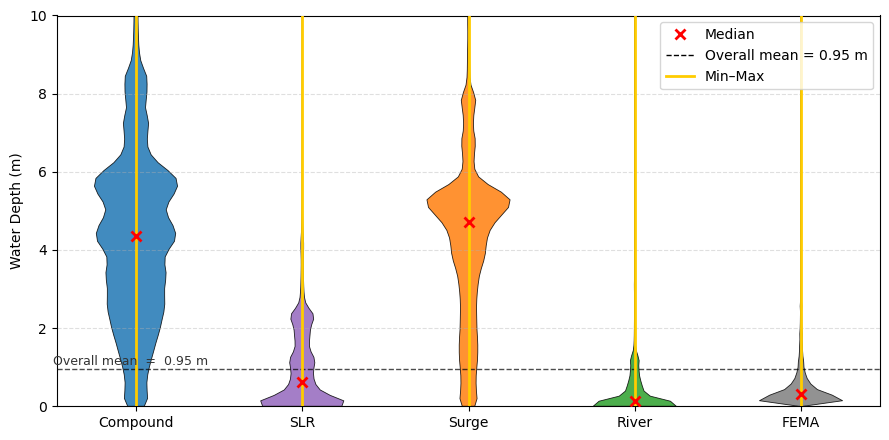

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------------------- INPUTS --------------------
paths = {
    "Compound": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
    "SLR":      r"D:\Phd Research\inundation depth only SLR.tif",
    "Surge":    r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    "River":    r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif",
    "FEMA":     r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif",
}

drop_below = 0.0     # keep depths strictly > this value; set to 0.1 if you want to ignore near-dry pixels
ymax = 10.0          # set to None for auto; set to 12.0 to match your figure
# title = "Water Depth Distributions"
# ------------------------------------------------

# Nice distinct colors (match your visual style)
colors = {
    "Compound": "#1f77b4",  # blue
    "SLR":      "#9467bd",  # puple (adjust if you want exact)
    "Surge":    "#ff7f0e",  # orange
    "River":    "#2ca02c",  # green
    "FEMA":     "#7f7f7f",  # gray
}
# If you prefer SLR bluish and Compound blue, tweak the dict above.

def read_depths(path, drop_below=0.0):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    if nodata is not None:
        valid = (arr != nodata) & np.isfinite(arr)
    else:
        valid = np.isfinite(arr)
    vals = arr[valid]
    if drop_below is not None:
        vals = vals[vals > drop_below]
    return vals

# Load all datasets
series = {}
for label, p in paths.items():
    vals = read_depths(p, drop_below=drop_below)
    if vals.size == 0:
        print(f"Warning: no valid depths found for {label}")
    series[label] = vals

# Prepare data for violinplot (list of arrays in consistent order)
labels = list(paths.keys())
data = [series[l] for l in labels]

# Overall mean across all drivers
all_vals = np.concatenate([v for v in data if v.size > 0])
overall_mean = float(np.mean(all_vals)) if all_vals.size else np.nan

# Create figure
fig, ax = plt.subplots(figsize=(9, 4.5))

# Violin plot (one per driver)
vp = ax.violinplot(
    data,
    showmeans=False,
    showextrema=False,   # we’ll draw our own whiskers
    showmedians=False
)

# Color each violin
for i, b in enumerate(vp['bodies']):
    b.set_facecolor(colors.get(labels[i], "#999999"))
    b.set_edgecolor("black")
    b.set_alpha(0.85)
    b.set_linewidth(0.6)

# Add median markers, whiskers (min–max), and a dot at max
for i, vals in enumerate(data, start=1):
    if vals.size == 0:
        continue
    vmin, vmed, vmax = float(np.min(vals)), float(np.median(vals)), float(np.max(vals))

    # yellow whisker line
    ax.vlines(i, vmin, vmax, color="#ffcc00", linewidth=2.0, zorder=3)
    # max marker
    ax.plot(i, vmax, marker="o", markersize=4.5, color="#ffcc00", zorder=4)

    # median red x
    ax.plot(i, vmed, marker="x", color="red", markersize=7, mew=2, zorder=5)

    # annotate max depth (optional)
    ax.annotate(
        f"Max depth {vmax:.1f} m",
        xy=(i, vmax),
        xytext=(i-0.35, vmax + (0.05 * (ymax if ymax else (np.nanmax(all_vals) if all_vals.size else 1)))),
        textcoords="data",
        fontsize=8,
        color="#444",
        arrowprops=dict(arrowstyle="-", color="#888", lw=0.8),
        ha="right"
    )

# Horizontal dashed line: overall mean
if np.isfinite(overall_mean):
    ax.axhline(overall_mean, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.text(
        0.5, overall_mean + 0.1,
        f"Overall mean  =  {overall_mean:.2f} m",
        color="#333", fontsize=9, ha="left"
    )

# Cosmetics
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Water Depth (m)")
ax.set_xlabel("")  # X label is the categories
# ax.set_title(title, loc="center")
if ymax is not None:
    ax.set_ylim(0, ymax)
else:
    # leave margin above max for annotations
    top = np.nanmax(all_vals) if all_vals.size else 1
    ax.set_ylim(0, top * 1.08)

# Legend elements
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker='x', color='red', linestyle='None', label='Median', markersize=7, mew=2),
    Line2D([0],[0], color='k', lw=1.0, linestyle='--', label=f'Overall mean = {overall_mean:.2f} m' if np.isfinite(overall_mean) else 'Overall mean'),
    Line2D([0],[0], color='#ffcc00', lw=2.0, label='Min–Max'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# # --- Optional: print quick stats ---
# for lbl, vals in zip(labels, data):
#     if vals.size:
#         print(f"{lbl:9s}  n={vals.size:>8,d}  min/median/mean/max = {np.min(vals):.2f} / {np.median(vals):.2f} / {np.mean(vals):.2f} / {np.max(vals):.2f} m")
#     else:
#         print(f"{lbl:9s}  n=0")


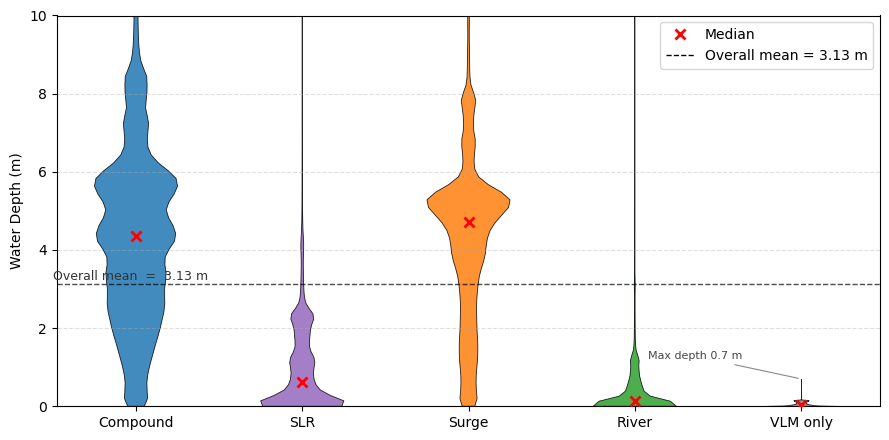

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- INPUTS --------------------
paths = {
    "Compound": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
    "SLR":      r"D:\Phd Research\inundation depth only SLR.tif",
    "Surge":    r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    "River":    r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif",
    "VLM only": r"D:\Phd Research\Final_Raster\VLM_only_depth.tif",   # << replaced FEMA
}

drop_below = 0.0     # set to 0.1 if you want to ignore near-dry pixels
ymax = 10.0          # set to None for auto
# ------------------------------------------------

# Nice distinct colors
colors = {
    "Compound": "#1f77b4",  # blue
    "SLR":      "#9467bd",  # purple
    "Surge":    "#ff7f0e",  # orange
    "River":    "#2ca02c",  # green
    "VLM only": "#7f7f7f",  # gray
}

def read_depths(path, drop_below=0.0):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    valid = np.isfinite(arr) if nodata is None else (np.isfinite(arr) & (arr != nodata))
    vals = arr[valid]
    if drop_below is not None:
        vals = vals[vals > drop_below]
    return vals

# Load all datasets
series = {}
for label, p in paths.items():
    vals = read_depths(p, drop_below=drop_below)
    if vals.size == 0:
        print(f"Warning: no valid depths found for {label}")
    series[label] = vals

# Prepare data for violinplot (list of arrays in consistent order)
labels = list(paths.keys())
data = [series[l] for l in labels]

# Overall mean across all drivers
all_vals = np.concatenate([v for v in data if v.size > 0]) if any(v.size for v in data) else np.array([])
overall_mean = float(np.mean(all_vals)) if all_vals.size else np.nan

# Figure
fig, ax = plt.subplots(figsize=(9, 4.5))
vp = ax.violinplot(data, showmeans=False, showextrema=False, showmedians=False)

# Color each violin
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors.get(labels[i], "#999999"))
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_linewidth(0.6)

# Add median, whiskers, and max marker
for i, vals in enumerate(data, start=1):
    if vals.size == 0:
        continue
    vmin, vmed, vmax = float(np.min(vals)), float(np.median(vals)), float(np.max(vals))
    # ax.vlines(i, vmin, vmax, color="#ffcc00", linewidth=2.0, zorder=3)                 # whisker
    # ax.plot(i, vmax, marker="o", markersize=4.5, color="#ffcc00", zorder=4)            # max dot
    ax.plot(i, vmed, marker="x", color="red", markersize=7, mew=2, zorder=5)           # median

    # annotate max depth (optional)
    ytop = ymax if ymax is not None else (np.nanmax(all_vals) if all_vals.size else 1)
    ax.annotate(
        f"Max depth {vmax:.1f} m",
        xy=(i, vmax),
        xytext=(i-0.35, vmax + 0.05 * ytop),
        textcoords="data",
        fontsize=8,
        color="#444",
        arrowprops=dict(arrowstyle="-", color="#888", lw=0.8),
        ha="right"
    )

# Overall mean line
if np.isfinite(overall_mean):
    ax.axhline(overall_mean, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.text(0.5, overall_mean + 0.1, f"Overall mean  =  {overall_mean:.2f} m",
            color="#333", fontsize=9, ha="left")

# Cosmetics
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Water Depth (m)")
if ymax is not None:
    ax.set_ylim(0, ymax)
else:
    top = np.nanmax(all_vals) if all_vals.size else 1
    ax.set_ylim(0, top * 1.08)

# Legend
legend_elems = [
    Line2D([0],[0], marker='x', color='red', linestyle='None', label='Median', markersize=7, mew=2),
    Line2D([0],[0], color='k', lw=1.0, linestyle='--', label=f'Overall mean = {overall_mean:.2f} m' if np.isfinite(overall_mean) else 'Overall mean'),
    # Line2D([0],[0], color='#ffcc00', lw=2.0, label='Min–Max'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


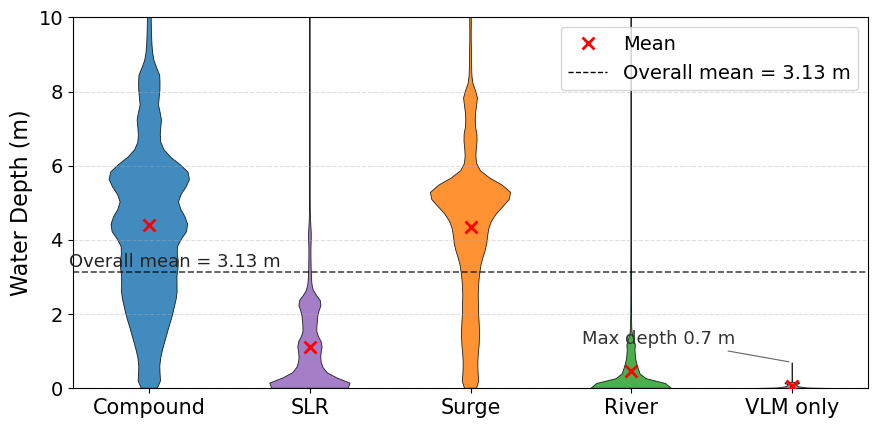

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- INPUTS --------------------
paths = {
    "Compound": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
    "SLR":      r"D:\Phd Research\inundation depth only SLR.tif",
    "Surge":    r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    "River":    r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif",
    "VLM only": r"D:\Phd Research\Final_Raster\VLM_only_depth.tif",   # << replaced FEMA
}

drop_below = 0.0     # set to 0.1 if you want to ignore near-dry pixels
ymax = 10.0          # set to None for auto
# ------------------------------------------------

# Nice distinct colors
colors = {
    "Compound": "#1f77b4",  # blue
    "SLR":      "#9467bd",  # purple
    "Surge":    "#ff7f0e",  # orange
    "River":    "#2ca02c",  # green
    "VLM only": "#7f7f7f",  # gray
}

def read_depths(path, drop_below=0.0):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    valid = np.isfinite(arr) if nodata is None else (np.isfinite(arr) & (arr != nodata))
    vals = arr[valid]
    if drop_below is not None:
        vals = vals[vals > drop_below]
    return vals

# Load all datasets
series = {}
for label, p in paths.items():
    vals = read_depths(p, drop_below=drop_below)
    if vals.size == 0:
        print(f"Warning: no valid depths found for {label}")
    series[label] = vals

# Prepare data for violinplot
labels = list(paths.keys())
data = [series[l] for l in labels]

# Overall mean across all drivers
all_vals = np.concatenate([v for v in data if v.size > 0]) if any(v.size for v in data) else np.array([])
overall_mean = float(np.mean(all_vals)) if all_vals.size else np.nan

# --- Matplotlib text size setup ---
plt.rcParams.update({
    'font.size': 14,         # base font size
    'axes.titlesize': 18,    # title size
    'axes.labelsize': 16,    # axis label
    'xtick.labelsize': 14,   # tick labels
    'ytick.labelsize': 14,
    'legend.fontsize': 14,   # legend text
    'figure.titlesize': 18
})

# Figure
fig, ax = plt.subplots(figsize=(9, 4.5))
vp = ax.violinplot(data, showmeans=False, showextrema=False, showmedians=False)

# Color each violin
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors.get(labels[i], "#999999"))
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_linewidth(0.6)

# Add median marker and max annotation
for i, vals in enumerate(data, start=1):
    if vals.size == 0:
        continue
    vmin, vmed, vmax = float(np.min(vals)), float(np.mean(vals)), float(np.max(vals))
    ax.plot(i, vmed, marker="x", color="red", markersize=9, mew=2, zorder=5)

    ytop = ymax if ymax is not None else (np.nanmax(all_vals) if all_vals.size else 1)
    ax.annotate(
        f"Max depth {vmax:.1f} m",
        xy=(i, vmax),
        xytext=(i - 0.35, vmax + 0.05 * ytop),
        textcoords="data",
        fontsize=13,
        color="#333",
        arrowprops=dict(arrowstyle="-", color="#666", lw=0.8),
        ha="right"
    )

# Overall mean line
if np.isfinite(overall_mean):
    ax.axhline(overall_mean, color="k", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(0.5, overall_mean + 0.15, f"Overall mean = {overall_mean:.2f} m",
            color="#222", fontsize=13, ha="left")

# Cosmetics
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=15)
ax.set_ylabel("Water Depth (m)", fontsize=16)
# ax.set_xlabel("Flood Driver", fontsize=16)
if ymax is not None:
    ax.set_ylim(0, ymax)
else:
    top = np.nanmax(all_vals) if all_vals.size else 1
    ax.set_ylim(0, top * 1.08)

# Legend
legend_elems = [
    Line2D([0],[0], marker='x', color='red', linestyle='None', label='Mean', markersize=9, mew=2),
    Line2D([0],[0], color='k', lw=1.0, linestyle='--', label=f'Overall mean = {overall_mean:.2f} m' if np.isfinite(overall_mean) else 'Overall mean'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


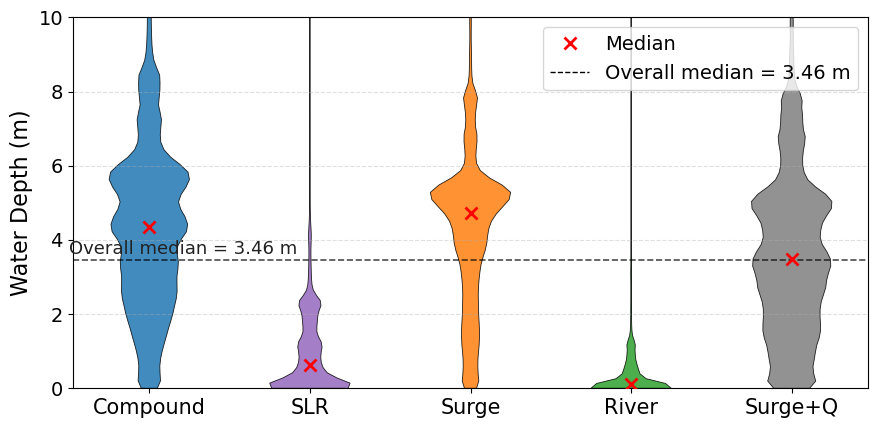

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- INPUTS --------------------
paths = {
    "Compound": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
    "SLR":      r"D:\Phd Research\inundation depth only SLR.tif",
    "Surge":    r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    "River":    r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif",
    "Surge+Q": r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr+Q_v1_stat.tif",   # << replaced FEMA
}

drop_below = 0.0     # set to 0.1 if you want to ignore near-dry pixels
ymax = 10.0          # set to None for auto
# ------------------------------------------------

# Nice distinct colors
colors = {
    "Compound": "#1f77b4",  # blue
    "SLR":      "#9467bd",  # purple
    "Surge":    "#ff7f0e",  # orange
    "River":    "#2ca02c",  # green
    "Surge+Q": "#7f7f7f",  # gray
}

def read_depths(path, drop_below=0.0):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    valid = np.isfinite(arr) if nodata is None else (np.isfinite(arr) & (arr != nodata))
    vals = arr[valid]
    if drop_below is not None:
        vals = vals[vals > drop_below]
    return vals

# Load all datasets
series = {}
for label, p in paths.items():
    vals = read_depths(p, drop_below=drop_below)
    if vals.size == 0:
        print(f"Warning: no valid depths found for {label}")
    series[label] = vals

# Prepare data for violinplot
labels = list(paths.keys())
data = [series[l] for l in labels]

# Overall median across all drivers
all_vals = np.concatenate([v for v in data if v.size > 0]) if any(v.size for v in data) else np.array([])
overall_median = float(np.median(all_vals)) if all_vals.size else np.nan

# --- Matplotlib text size setup ---
plt.rcParams.update({
    'font.size': 14,         # base font size
    'axes.titlesize': 18,    # title size
    'axes.labelsize': 16,    # axis label
    'xtick.labelsize': 14,   # tick labels
    'ytick.labelsize': 14,
    'legend.fontsize': 14,   # legend text
    'figure.titlesize': 18
})

# Figure
fig, ax = plt.subplots(figsize=(9, 4.5))
vp = ax.violinplot(data, showmeans=False, showextrema=False, showmedians=False)

# Color each violin
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors.get(labels[i], "#999999"))
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_linewidth(0.6)

# Add median marker and max annotation
for i, vals in enumerate(data, start=1):
    if vals.size == 0:
        continue
    vmin, vmed, vmax = float(np.min(vals)), float(np.median(vals)), float(np.max(vals))
    ax.plot(i, vmed, marker="x", color="red", markersize=9, mew=2, zorder=5)

    ytop = ymax if ymax is not None else (np.nanmax(all_vals) if all_vals.size else 1)
    ax.annotate(
        f"Max depth {vmax:.1f} m",
        xy=(i, vmax),
        xytext=(i - 0.35, vmax + 0.05 * ytop),
        textcoords="data",
        fontsize=13,
        color="#333",
        arrowprops=dict(arrowstyle="-", color="#666", lw=0.8),
        ha="right"
    )

# Overall median line
if np.isfinite(overall_median):
    ax.axhline(overall_median, color="k", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(0.5, overall_median + 0.15, f"Overall median = {overall_median:.2f} m",
            color="#222", fontsize=13, ha="left")

# Cosmetics
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=15)
ax.set_ylabel("Water Depth (m)", fontsize=16)
# ax.set_xlabel("Flood Driver", fontsize=16)
if ymax is not None:
    ax.set_ylim(0, ymax)
else:
    top = np.nanmax(all_vals) if all_vals.size else 1
    ax.set_ylim(0, top * 1.08)

# Legend
legend_elems = [
    Line2D([0],[0], marker='x', color='red', linestyle='None', label='Median', markersize=9, mew=2),
    Line2D([0],[0], color='k', lw=1.0, linestyle='--', label=f'Overall median = {overall_median:.2f} m' if np.isfinite(overall_median) else 'Overall median'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


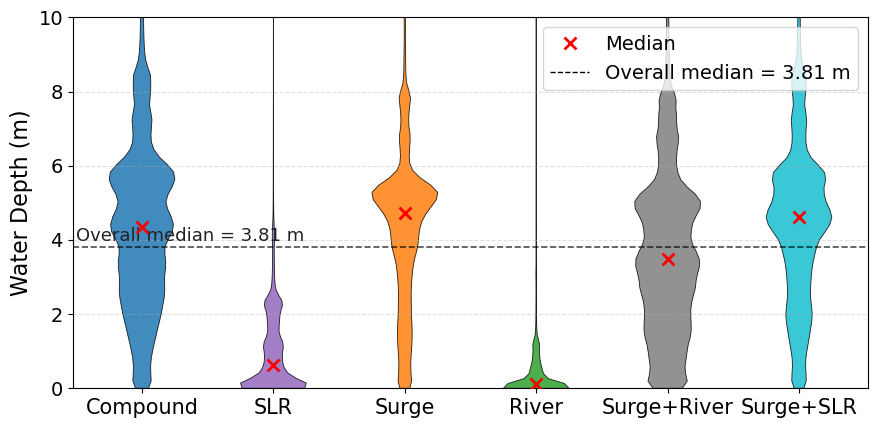

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- INPUTS --------------------
paths = {
    "Compound": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
    "SLR":      r"D:\Phd Research\inundation depth only SLR.tif",
    "Surge":    r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    "River":    r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif",
    "Surge+River": r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr+Q_v1_stat.tif",   # << replaced FEMA
    "Surge+SLR": r"D:\Phd Research\Final_Raster\inundation for only storm surge+SLR 100 yr_v2_stat.tif",
}

drop_below = 0.0     # set to 0.1 if you want to ignore near-dry pixels
ymax = 10.0          # set to None for auto
# ------------------------------------------------

# Nice distinct colors
colors = {
    "Compound": "#1f77b4",  # blue
    "SLR":      "#9467bd",  # purple
    "Surge":    "#ff7f0e",  # orange
    "River":    "#2ca02c",  # green
    "Surge+River": "#7f7f7f",  # gray
    "Surge+SLR": "#17becf",  # teal
}

def read_depths(path, drop_below=0.0):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    valid = np.isfinite(arr) if nodata is None else (np.isfinite(arr) & (arr != nodata))
    vals = arr[valid]
    if drop_below is not None:
        vals = vals[vals > drop_below]
    return vals

# Load all datasets
series = {}
for label, p in paths.items():
    vals = read_depths(p, drop_below=drop_below)
    if vals.size == 0:
        print(f"Warning: no valid depths found for {label}")
    series[label] = vals

# Prepare data for violinplot
labels = list(paths.keys())
data = [series[l] for l in labels]

# Overall median across all drivers
all_vals = np.concatenate([v for v in data if v.size > 0]) if any(v.size for v in data) else np.array([])
overall_median = float(np.median(all_vals)) if all_vals.size else np.nan

# --- Matplotlib text size setup ---
plt.rcParams.update({
    'font.size': 14,         # base font size
    'axes.titlesize': 18,    # title size
    'axes.labelsize': 16,    # axis label
    'xtick.labelsize': 14,   # tick labels
    'ytick.labelsize': 14,
    'legend.fontsize': 14,   # legend text
    'figure.titlesize': 18
})

# Figure
fig, ax = plt.subplots(figsize=(9, 4.5))
vp = ax.violinplot(data, showmeans=False, showextrema=False, showmedians=False)

# Color each violin
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors.get(labels[i], "#999999"))
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_linewidth(0.6)

# Add median marker and max annotation
for i, vals in enumerate(data, start=1):
    if vals.size == 0:
        continue
    vmin, vmed, vmax = float(np.min(vals)), float(np.median(vals)), float(np.max(vals))
    ax.plot(i, vmed, marker="x", color="red", markersize=9, mew=2, zorder=5)

    ytop = ymax if ymax is not None else (np.nanmax(all_vals) if all_vals.size else 1)
    ax.annotate(
        f"Max depth {vmax:.1f} m",
        xy=(i, vmax),
        xytext=(i - 0.35, vmax + 0.05 * ytop),
        textcoords="data",
        fontsize=13,
        color="#333",
        arrowprops=dict(arrowstyle="-", color="#666", lw=0.8),
        ha="right"
    )

# Overall median line
if np.isfinite(overall_median):
    ax.axhline(overall_median, color="k", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(0.5, overall_median + 0.15, f"Overall median = {overall_median:.2f} m",
            color="#222", fontsize=13, ha="left")

# Cosmetics
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=15)
ax.set_ylabel("Water Depth (m)", fontsize=16)
# ax.set_xlabel("Flood Driver", fontsize=16)
if ymax is not None:
    ax.set_ylim(0, ymax)
else:
    top = np.nanmax(all_vals) if all_vals.size else 1
    ax.set_ylim(0, top * 1.08)

# Legend
legend_elems = [
    Line2D([0],[0], marker='x', color='red', linestyle='None', label='Median', markersize=9, mew=2),
    Line2D([0],[0], color='k', lw=1.0, linestyle='--', label=f'Overall median = {overall_median:.2f} m' if np.isfinite(overall_median) else 'Overall median'),
]
ax.legend(handles=legend_elems, loc='upper right', frameon=True)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
